# FOVs as vectors in rule space  -  positive rules

Each FOV is a row of rule strengths; PCA asks which FOVs have similar rules.


In [2]:
import os
import sys

sys.path.append(os.path.abspath('../..'))   # project root
sys.path.append(os.path.abspath('..'))            # shared helpers, one level up

import rule_space_helper as rs
# Which mining run: data_helper.RESULT_CSV_PATH, shared by every notebook.
# To read a different one, pass its path to dh.load_results / rs.load below.


In [3]:
# --- Settings for this run. Everything else is left at the helper's default. ---
rs.METRIC            = 'Lift'
rs.POSITIVE_ONLY     = True
rs.RULE_MAX_ITEMS    = 2
rs.NO_SELF           = True
rs.MIN_FOV_THRESHOLD = 0.02
rs.SCORE_COL         = 'Pathological score'

data = rs.load()


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.
Kept 489672 rules at FDR <= 0.05.
Kept 102887 rules that add information.
Kept 102887 rules (max_items=4, kind=None).


## 1. All FOVs

Every stage and both organs. The two scatters are the same PCA coloured twice, so they can be compared directly.


both organs, all stages: 262 FOVs x 95 columns  |  PC1 6.1%  PC2 3.9%
saved summary_downloads\pos_all_pca_organ.pdf


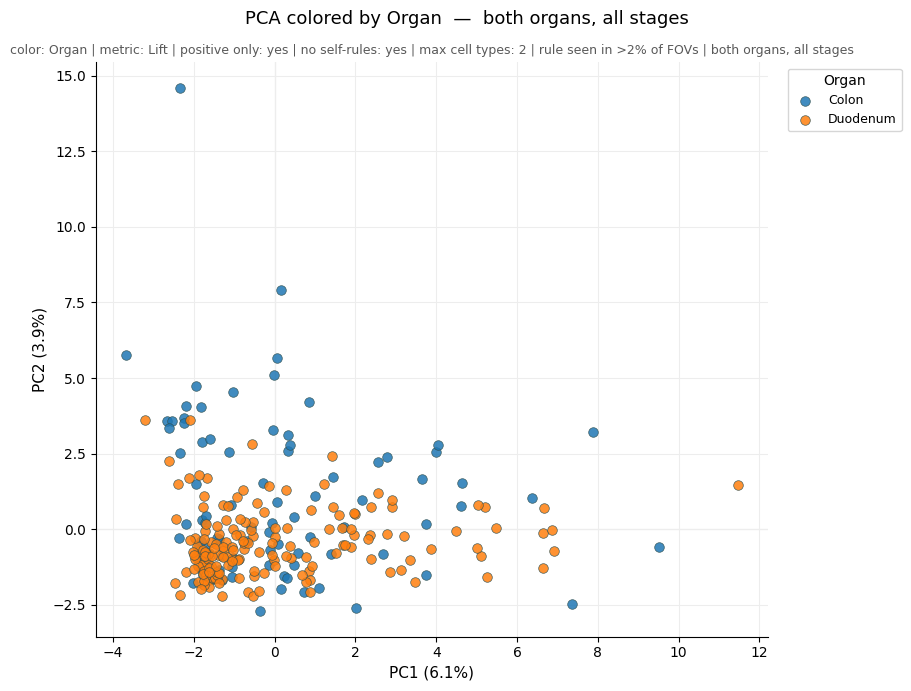

In [4]:
all_fovs = rs.run(data,
                   prefix='pos_all', diagnostics=False)

rs.scatter(all_fovs, color_by='Organ', save=True);   # the clean PCA, no labels

## 1.1. Colon, all stages

Every stage of one organ. The colourings below are the biopsy metadata - days after the
transplant, donor type, cortico response, survival - which need all the stages present to
be worth asking about.


Colon, all stages: 93 FOVs x 111 columns  |  PC1 6.7%  PC2 5.2%


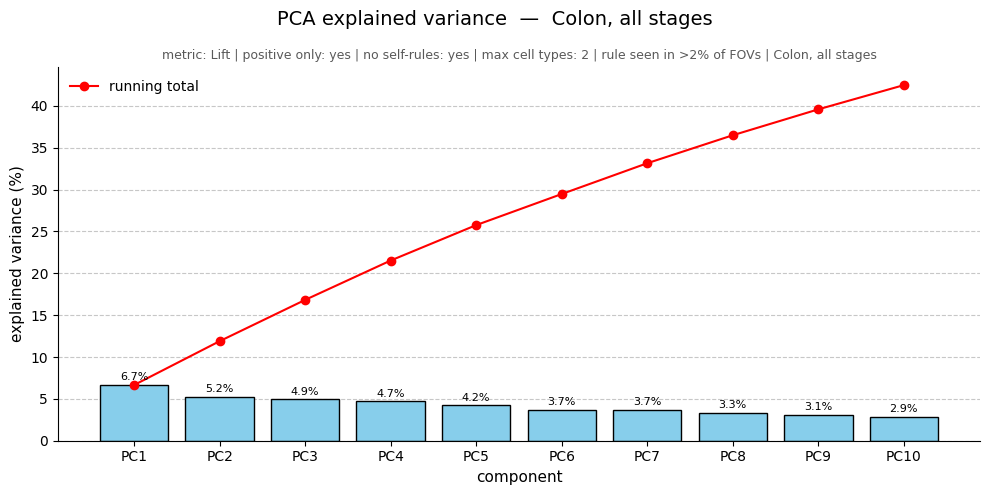

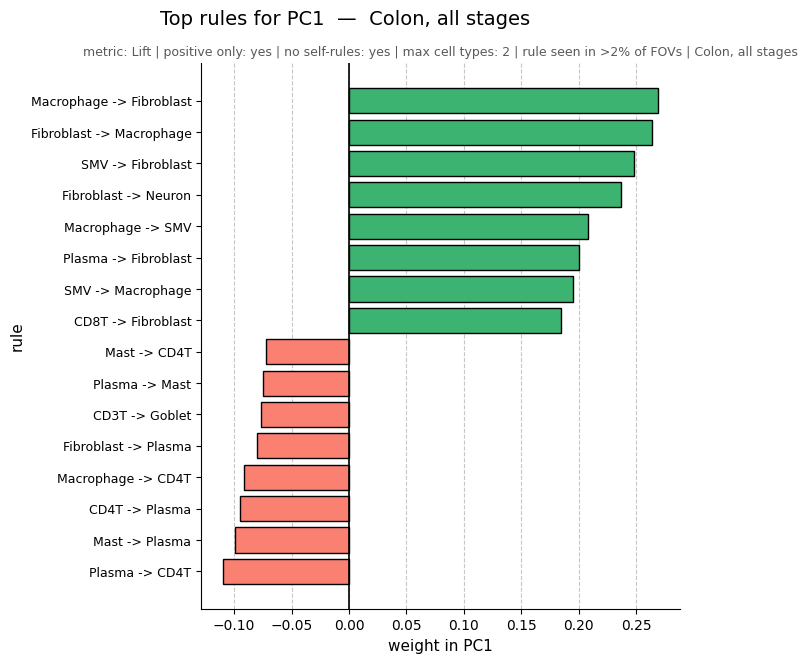

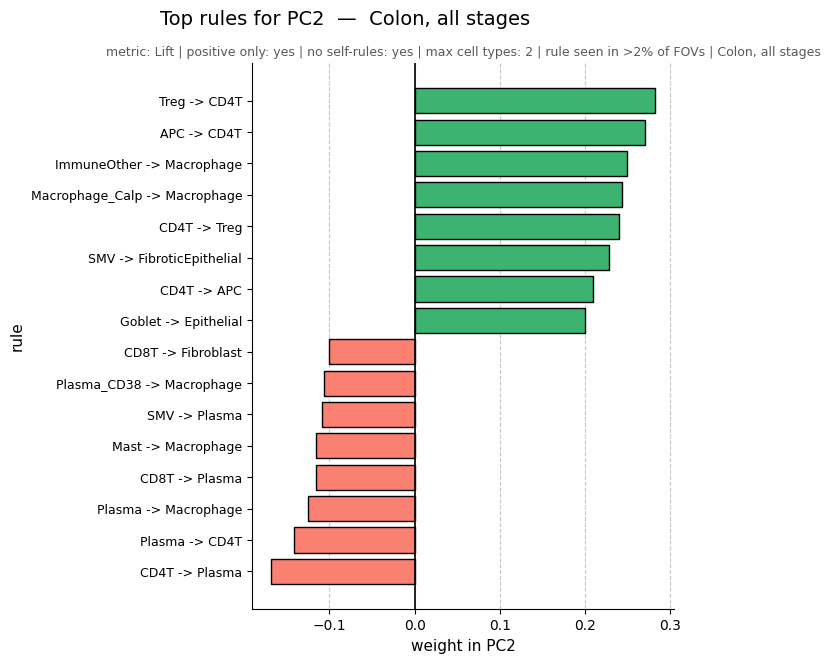

In [5]:
colon_all = rs.run(data,
                    organs=['Colon'], prefix='pos_colon')


## 1.2. Duodenum, all stages

Every stage of one organ. The colourings below are the biopsy metadata - days after the
transplant, donor type, cortico response, survival - which need all the stages present to
be worth asking about.


Duodenum, all stages: 168 FOVs x 95 columns  |  PC1 6.6%  PC2 4.2%


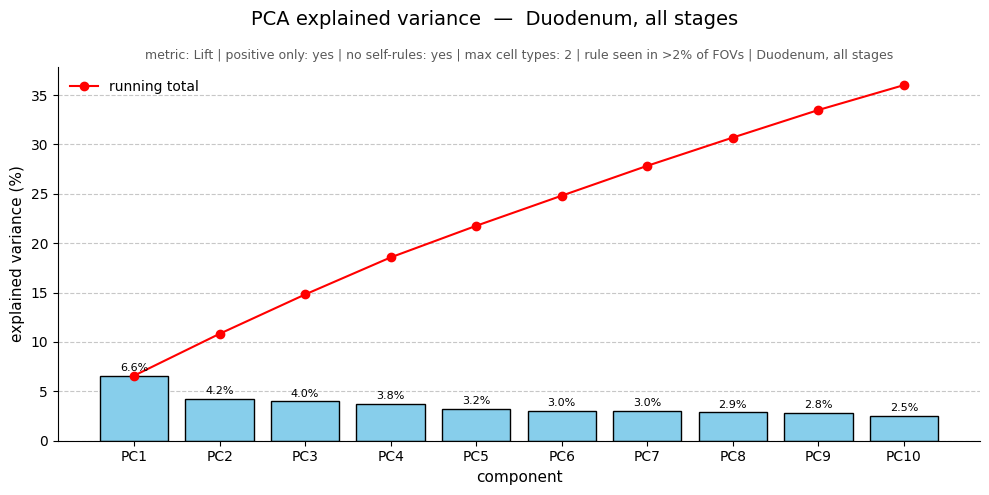

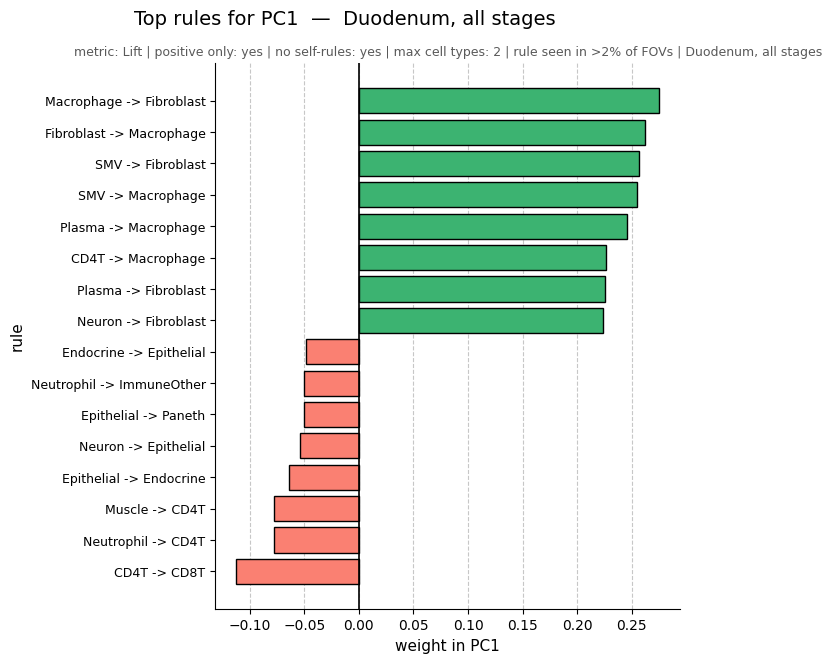

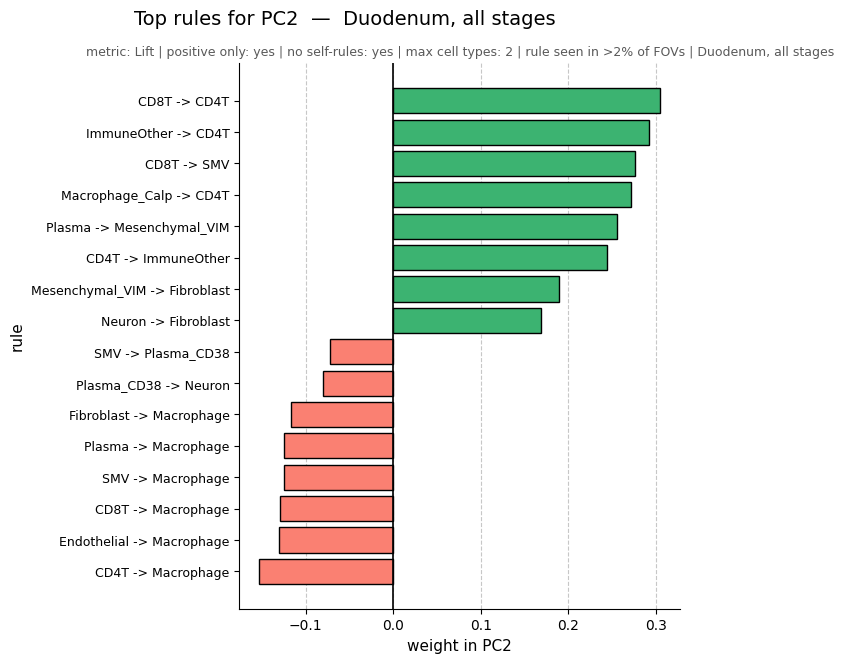

In [6]:
duodenum_all = rs.run(data,
                       organs=['Duodenum'], prefix='pos_duodenum')


## 2. Colon, Control vs Severe

The two extreme stages inside one organ, so neither organ nor the middle stages can explain a split.


In [7]:
control_severe_colon = rs.run(data,
                               stages=['Control', 'Severe'], organs=['Colon'],
                               prefix='pos_cs_colon', diagnostics=False)


Colon, Control vs Severe: 55 FOVs x 90 columns  |  PC1 9.3%  PC2 6.7%


saved summary_downloads\pos_cs_colon_pca_pathological_score.pdf


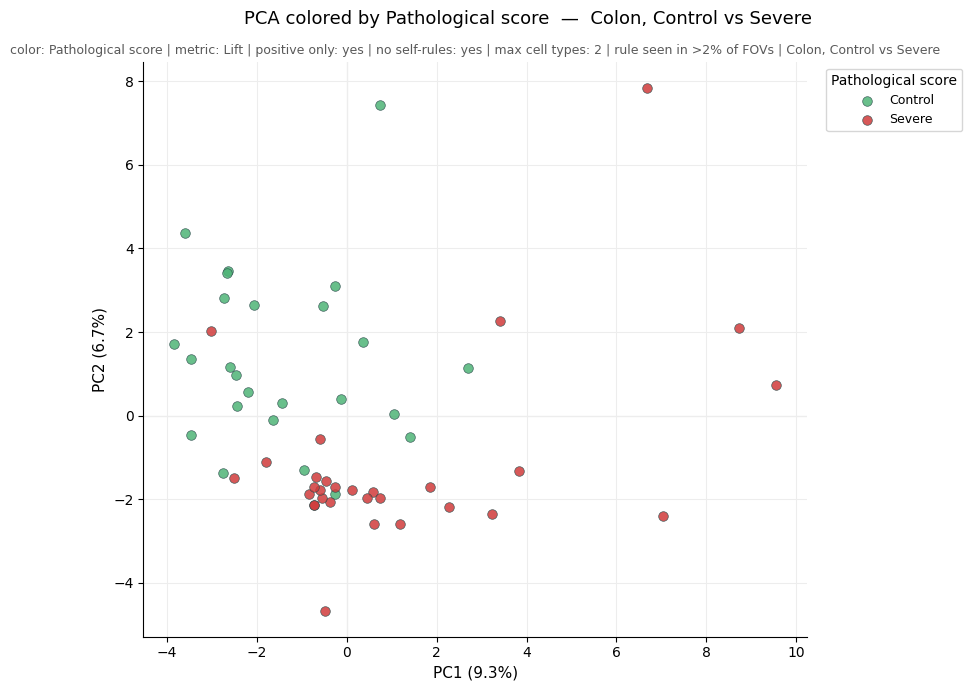

In [8]:
rs.scatter(control_severe_colon, save=True);   # the clean PCA, no labels

## 3. Duodenum, Control vs Severe

The same two stages in the other organ.


In [9]:
control_severe_duodenum = rs.run(data,
                                  stages=['Control', 'Severe'], organs=['Duodenum'],
                                  prefix='pos_cs_duodenum', diagnostics=False)


Duodenum, Control vs Severe: 67 FOVs x 93 columns  |  PC1 8.3%  PC2 7.9%


saved summary_downloads\pos_cs_duodenum_pca_pathological_score.pdf


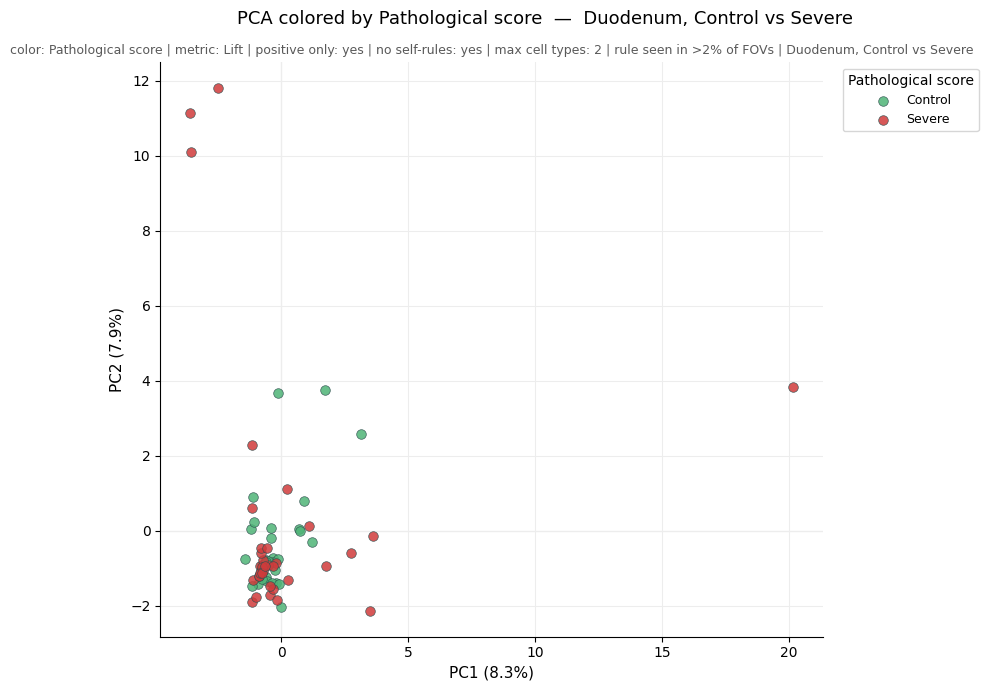

In [10]:
rs.scatter(control_severe_duodenum, save=True);   # the clean PCA, no labels

## 4. Colon, Mild vs Severe

The two disease stages, without the healthy controls.


In [11]:
mild_severe_colon = rs.run(data,
                            stages=['Mild', 'Severe'], organs=['Colon'],
                            prefix='pos_ms_colon', diagnostics=False)


Colon, Mild vs Severe: 68 FOVs x 89 columns  |  PC1 9.1%  PC2 6.9%


saved summary_downloads\pos_ms_colon_pca_pathological_score.pdf


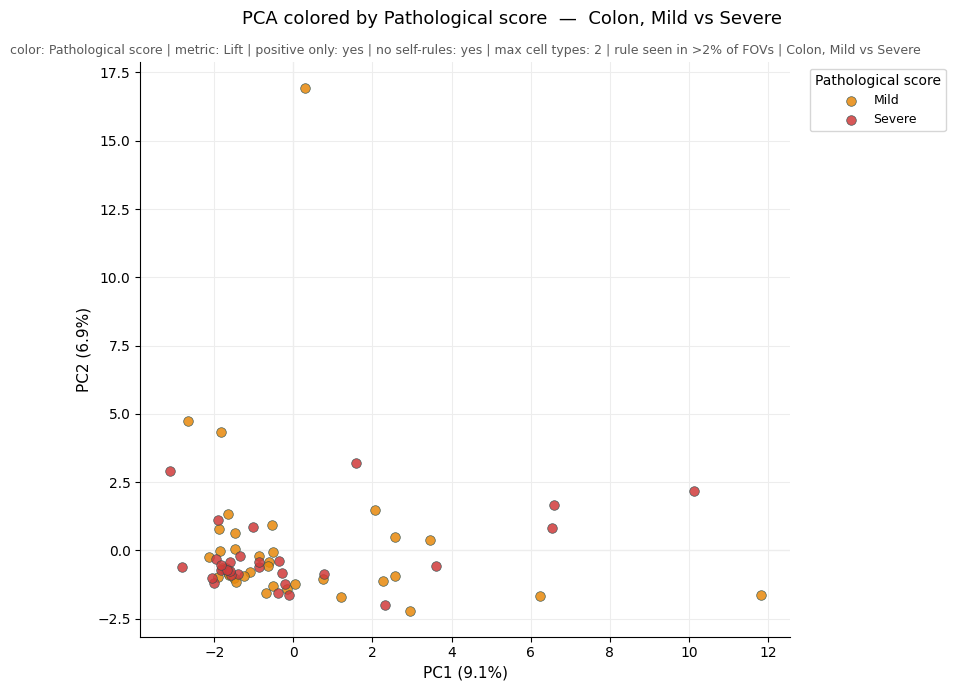

In [12]:
rs.scatter(mild_severe_colon, save=True);   # the clean PCA, no labels

## 5. Duodenum, Mild vs Severe

The same two stages in the other organ.


In [13]:
mild_severe_duodenum = rs.run(data,
                               stages=['Mild', 'Severe'], organs=['Duodenum'],
                               prefix='pos_ms_duodenum', diagnostics=False)


Duodenum, Mild vs Severe: 137 FOVs x 110 columns  |  PC1 6.1%  PC2 4.0%


saved summary_downloads\pos_ms_duodenum_pca_pathological_score.pdf


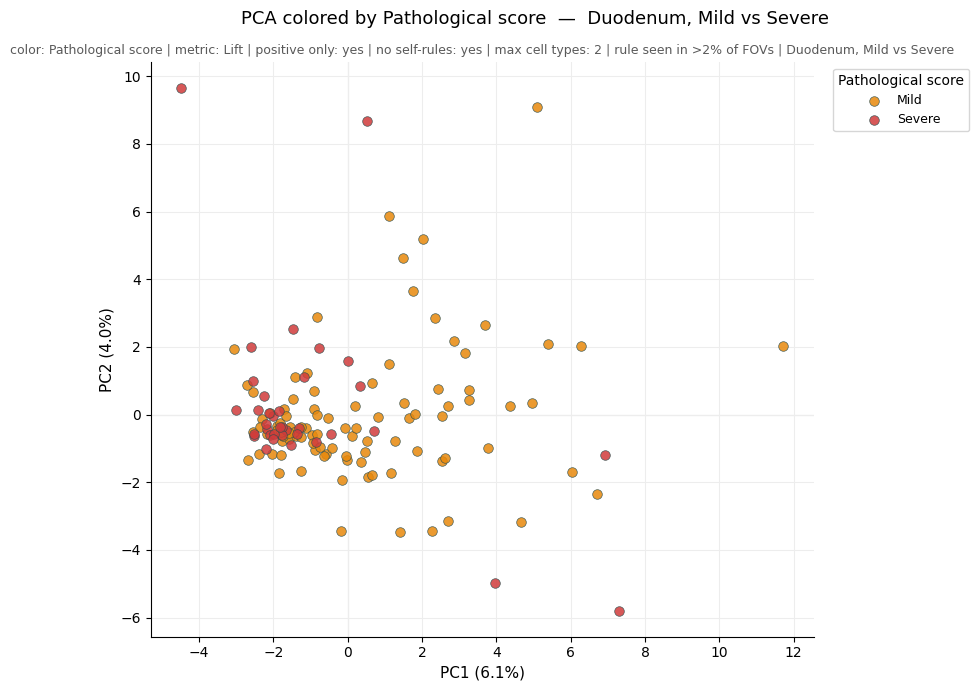

: 

In [ ]:
rs.scatter(mild_severe_duodenum, save=True);   # the clean PCA, no labels